<a href="https://colab.research.google.com/github/bdashti/v/blob/main/Copy_of_Phase_3_Figures_colab_v4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#@title Setup Cell
# ----- setup -----
import os, warnings
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

try:
    from google.colab import drive
    if not os.path.isdir('/content/drive/MyDrive'):
        drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/Plasmids'
except Exception:
    BASE = '.'   # running outside Colab

SAVEPOINT = f'{BASE}/phase2_savepoints/sp_20260612_200020'
# Phase 1 df_test predictions (copy this CSV from your Windows export to Drive once).
# Expected columns: a measured-LFC column and a calibrated-prediction column.
DF_TEST_CSV = f'{BASE}/exports/df_test_predictions.csv'
DF_TEST_PKL = f'{BASE}/sp4_df_test.pkl'   # Phase 1 df_test pickle (copied to Drive)
COLOC_NPZ   = f'{BASE}/streme_outputs/colocalisation_k3_null.npz'

OUTDIR = f'{BASE}/figures' if BASE != '.' else 'figures'
os.makedirs(OUTDIR, exist_ok=True)

plt.rcParams.update({
    'font.size': 10.5, 'axes.titlesize': 11.5, 'axes.labelsize': 10.5,
    'axes.spines.top': False, 'axes.spines.right': False,
    'xtick.labelsize': 9.5, 'ytick.labelsize': 9.5, 'legend.fontsize': 9,
    'figure.dpi': 110, 'savefig.facecolor': 'white', 'axes.grid': False,
})
COL = {'comp': '#C24646', 'alt': '#9AA0A6', 'stable': '#2E7DB1',
       'hi': '#E0922F', 'ceil': '#5A5A5A', 'pos': '#2E7DB1', 'neg': '#C24646'}

def save_fig(fig, name):
    for ext in ('png', 'pdf'):
        fig.savefig(f'{OUTDIR}/{name}.{ext}', dpi=600, bbox_inches='tight')
    print('saved', f'{OUTDIR}/{name}.png')

def panel_letter(ax, s):
    ax.text(-0.1, 1.06, s, transform=ax.transAxes, fontsize=13, fontweight='bold',
            va='bottom', ha='right')

def load_globals():
    try:
        import joblib
        g = joblib.load(f'{SAVEPOINT}/globals.joblib')
        return g if isinstance(g, dict) else {}
    except Exception as e:
        print('  [globals not loaded:', e, ']'); return {}

print('setup ok; OUTDIR =', OUTDIR)


setup ok; OUTDIR = /content/drive/MyDrive/Plasmids/figures


saved /content/drive/MyDrive/Plasmids/figures/Fig2_supervised_performance.png


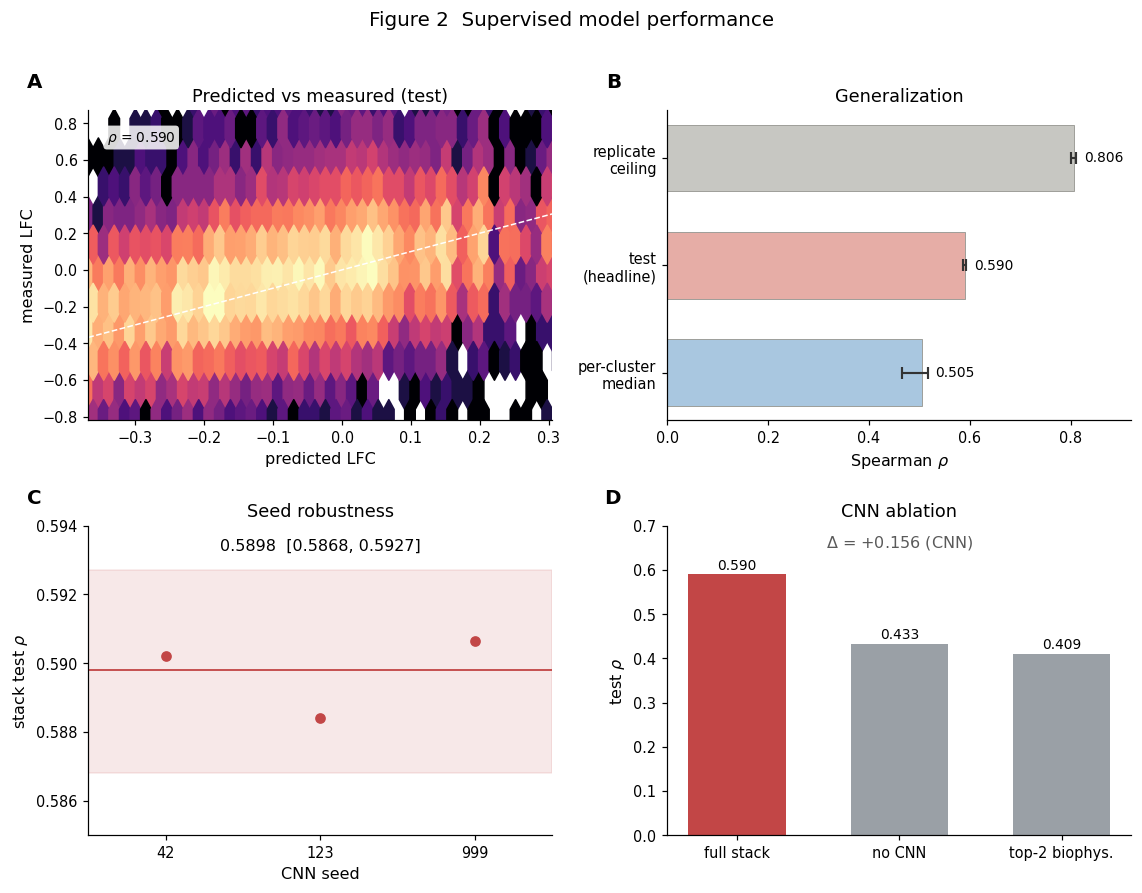

In [ ]:
#@title Figure 2 — supervised performance
fig, ax = plt.subplots(2, 2, figsize=(10.5, 8))

# 2A predicted vs measured.
DF_TEST_PKL = f'{BASE}/sp4_df_test.pkl'
a = ax[0, 0]
def _find(cols, subs):
    for c in cols:
        if any(s in c.lower() for s in subs):
            return c
    return None
try:
    import pandas as pd
    _g = globals().get('df_test', None)
    d = _g if (_g is not None and hasattr(_g, 'columns')) else pd.read_pickle(DF_TEST_PKL)
    meas = _find(d.columns, ['log2fc', 'lfc', 'measured'])
    pred = _find(d.columns, ['stack_pred_calib', 'pred_calib', 'pred'])
    md, pr = d[meas].to_numpy(float), d[pred].to_numpy(float)
    ok = np.isfinite(md) & np.isfinite(pr)
    a.hexbin(pr[ok], md[ok], gridsize=45, mincnt=1, cmap='magma', bins='log')
    xlo, xhi = np.percentile(pr[ok], [1, 99])
    a.plot([xlo, xhi], [xlo, xhi], color='w', lw=1, ls='--')
    a.set_xlim(xlo, xhi); a.set_ylim(*np.percentile(md[ok], [1, 99]))
    a.set_xlabel('predicted LFC'); a.set_ylabel('measured LFC')
    a.text(0.04, 0.94, r'$\rho$ = 0.590', transform=a.transAxes, color='k', fontsize=9, va='top',
           bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='none', alpha=0.85))
except Exception as e:
    a.text(0.5, 0.5, f'df_test not found\n({DF_TEST_PKL})',
           ha='center', va='center', transform=a.transAxes, color=COL['alt'], fontsize=9)
    a.set_xticks([]); a.set_yticks([])
a.set_title('Predicted vs measured (test)')
panel_letter(a, 'A')

# 2B generalization (horizontal bar chart, pale bars so CI whiskers read clearly)
b = ax[0, 1]
labels = ['replicate\nceiling', 'test\n(headline)', 'per-cluster\nmedian']
vals = [0.8062, 0.5898, 0.5046]
lo = [0.8012, 0.5868, 0.4652]; hi = [0.8110, 0.5927, 0.5168]
err = [[v - l for v, l in zip(vals, lo)], [h - v for v, h in zip(vals, hi)]]
pale = ['#C7C7C2', '#E6ADA6', '#A9C7E0']   # pale grey / coral / blue
y = np.arange(len(labels))
b.barh(y, vals, xerr=err, height=0.62, color=pale, edgecolor='#9A9A95', linewidth=0.6,
       capsize=4, error_kw=dict(ecolor='#333333', lw=1.4, capthick=1.4))
for i, v in enumerate(vals):
    b.text(v + err[1][i] + 0.015, i, f'{v:.3f}', va='center', fontsize=9)
b.set_yticks(y); b.set_yticklabels(labels); b.invert_yaxis()
b.set_xlim(0, 0.92); b.set_xlabel(r'Spearman $\rho$')
b.set_title('Generalization'); panel_letter(b, 'B')

# 2C 3-seed CI
c = ax[1, 0]
seeds = [0.590217, 0.588417, 0.590639]
mean, clo, chi = 0.5898, 0.5868, 0.5927
c.axhspan(clo, chi, color=COL['comp'], alpha=0.12)
c.axhline(mean, color=COL['comp'], lw=1.2)
xpos = np.arange(len(seeds))
c.scatter(xpos, seeds, color=COL['comp'], zorder=3, s=36)
c.set_xticks(xpos); c.set_xticklabels(['42', '123', '999']); c.set_xlabel('CNN seed')
c.set_xlim(-0.5, 2.5)
c.set_ylabel(r'stack test $\rho$'); c.set_ylim(0.585, 0.594)
c.text(0.5, 0.92, '0.5898  [0.5868, 0.5927]', transform=c.transAxes, ha='center')
c.set_title('Seed robustness'); panel_letter(c, 'C')

# 2D CNN ablation (no connector line)
d2 = ax[1, 1]
albl = ['full stack', 'no CNN', 'top-2 biophys.']
av = [0.5895, 0.4331, 0.4093]
bars = d2.bar(albl, av, color=[COL['comp'], COL['alt'], COL['alt']], width=0.6)
d2.set_ylabel(r'test $\rho$'); d2.set_ylim(0, 0.7)
for r, v in zip(bars, av):
    d2.text(r.get_x() + r.get_width() / 2, v + 0.012, f'{v:.3f}', ha='center', fontsize=9)
d2.text(0.5, 0.93, r'$\Delta$ = +0.156 (CNN)', transform=d2.transAxes, ha='center', color=COL['ceil'])
d2.set_title('CNN ablation'); panel_letter(d2, 'D')

fig.suptitle('Figure 2  Supervised model performance', y=1.01, fontsize=13)
fig.tight_layout()
save_fig(fig, 'Fig2_supervised_performance')

saved /content/drive/MyDrive/Plasmids/figures/Fig3_composition.png


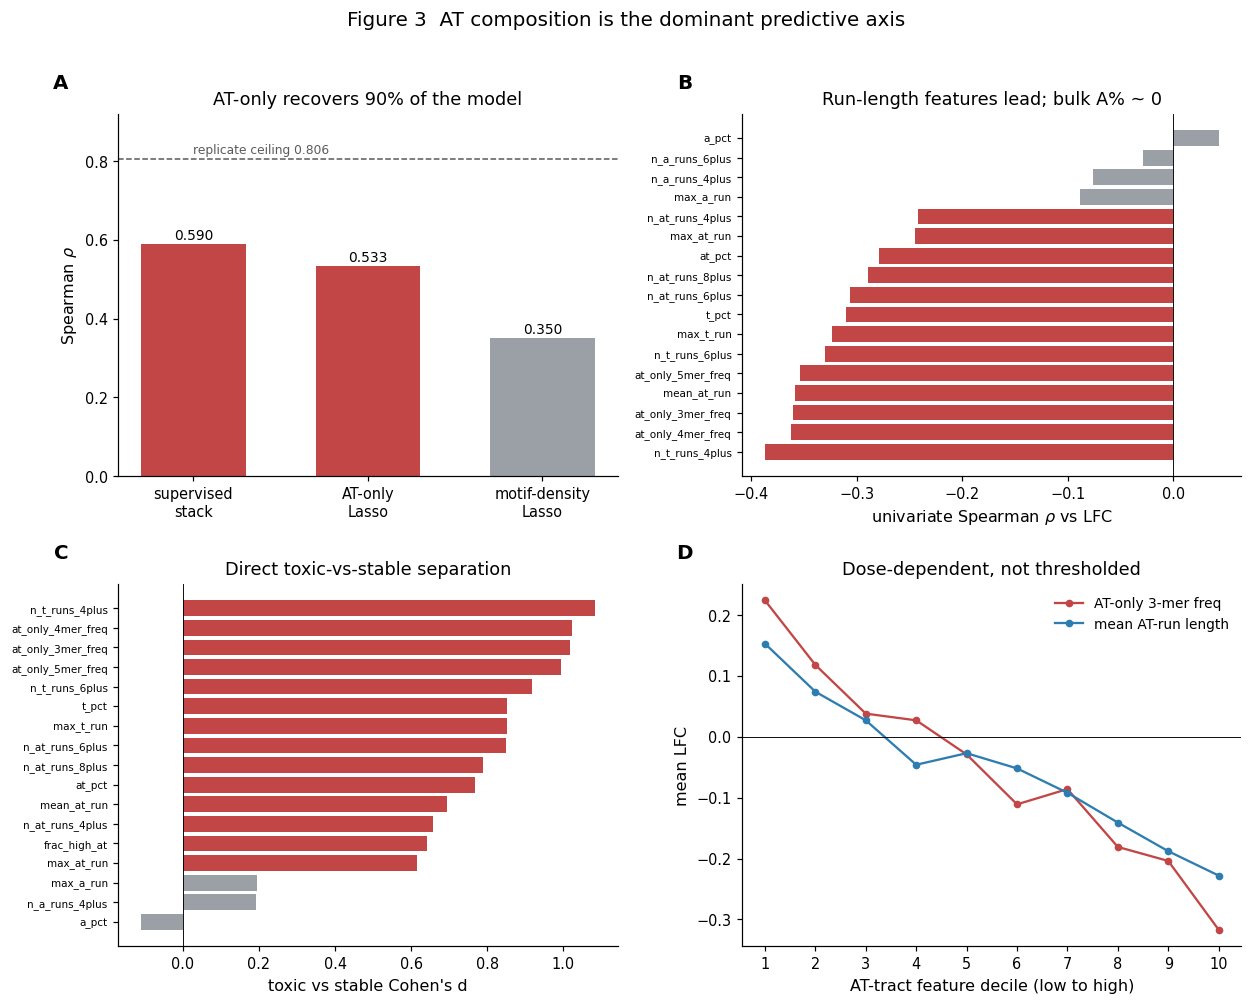

In [ ]:
#@title Figure 3 — composition is the predictive axis
fig, ax = plt.subplots(2, 2, figsize=(11.5, 9))

# 3A model comparison
a = ax[0, 0]
models = ['supervised\nstack', 'AT-only\nLasso', 'motif-density\nLasso']
vals = [0.5895, 0.5331, 0.3501]
a.bar(models, vals, color=[COL['comp'], COL['comp'], COL['alt']], width=0.6)
a.axhline(0.8062, color=COL['ceil'], ls='--', lw=1)
a.text(0.0, 0.8062 + 0.012, 'replicate ceiling 0.806', ha='left', fontsize=8, color=COL['ceil'])
for i, v in enumerate(vals):
    a.text(i, v + 0.012, f'{v:.3f}', ha='center', fontsize=9)
a.set_ylim(0, 0.92); a.set_ylabel(r'Spearman $\rho$')
a.set_title('AT-only recovers 90% of the model'); panel_letter(a, 'A')

# 3B AT-feature univariate ranking (Cell 25)
b = ax[0, 1]
feats = [('n_t_runs_4plus', -0.387), ('at_only_4mer_freq', -0.362), ('at_only_3mer_freq', -0.360),
         ('mean_at_run', -0.359), ('at_only_5mer_freq', -0.354), ('n_t_runs_6plus', -0.330),
         ('max_t_run', -0.323), ('t_pct', -0.310), ('n_at_runs_6plus', -0.306),
         ('n_at_runs_8plus', -0.289), ('at_pct', -0.279), ('max_at_run', -0.245),
         ('n_at_runs_4plus', -0.242), ('max_a_run', -0.088), ('n_a_runs_4plus', -0.076),
         ('a_pct', 0.043), ('n_a_runs_6plus', -0.029)]
feats = sorted(feats, key=lambda x: x[1])
names = [f[0] for f in feats]; vals = [f[1] for f in feats]
cols = [COL['comp'] if abs(v) >= 0.20 else COL['alt'] for v in vals]
b.barh(range(len(names)), vals, color=cols)
b.set_yticks(range(len(names))); b.set_yticklabels(names, fontsize=6.8)
b.axvline(0, color='k', lw=0.6); b.set_xlabel(r'univariate Spearman $\rho$ vs LFC')
b.set_title('Run-length features lead; bulk A% ~ 0'); panel_letter(b, 'B')

# 3C direct toxic-vs-stable separation (Cell 27a)
c = ax[1, 0]
d27 = [('n_t_runs_4plus', 1.083), ('at_only_4mer_freq', 1.024), ('at_only_3mer_freq', 1.018),
       ('at_only_5mer_freq', 0.993), ('n_t_runs_6plus', 0.918), ('t_pct', 0.853),
       ('max_t_run', 0.851), ('n_at_runs_6plus', 0.850), ('n_at_runs_8plus', 0.788),
       ('at_pct', 0.767), ('mean_at_run', 0.694), ('n_at_runs_4plus', 0.658),
       ('frac_high_at', 0.641), ('max_at_run', 0.615), ('max_a_run', 0.194),
       ('n_a_runs_4plus', 0.192), ('a_pct', -0.110)]
d27 = sorted(d27, key=lambda x: x[1])
names = [x[0] for x in d27]; vals = [x[1] for x in d27]
cols = [COL['comp'] if v >= 0.5 else COL['alt'] for v in vals]
c.barh(range(len(names)), vals, color=cols)
c.set_yticks(range(len(names))); c.set_yticklabels(names, fontsize=6.8)
c.axvline(0, color='k', lw=0.6); c.set_xlabel(r"toxic vs stable Cohen's d")
c.set_title('Direct toxic-vs-stable separation'); panel_letter(c, 'C')

# 3D dose-response (Cell 27b)
d = ax[1, 1]
x = list(range(1, 11))
y1 = [0.224, 0.118, 0.038, 0.027, -0.029, -0.111, -0.086, -0.181, -0.204, -0.317]
y2 = [0.153, 0.074, 0.027, -0.046, -0.027, -0.052, -0.092, -0.141, -0.188, -0.228]
d.plot(x, y1, '-o', color=COL['comp'], ms=4, label='AT-only 3-mer freq')
d.plot(x, y2, '-o', color=COL['stable'], ms=4, label='mean AT-run length')
d.axhline(0, color='k', lw=0.6)
d.set_xlabel('AT-tract feature decile (low to high)'); d.set_ylabel('mean LFC')
d.set_xticks(x); d.legend(frameon=False, loc='upper right')
d.set_title('Dose-dependent, not thresholded'); panel_letter(d, 'D')

fig.suptitle('Figure 3  AT composition is the dominant predictive axis', y=1.01, fontsize=13)
fig.tight_layout()
save_fig(fig, 'Fig3_composition')


saved /content/drive/MyDrive/Plasmids/figures/Fig4_unsupervised_motifs.png


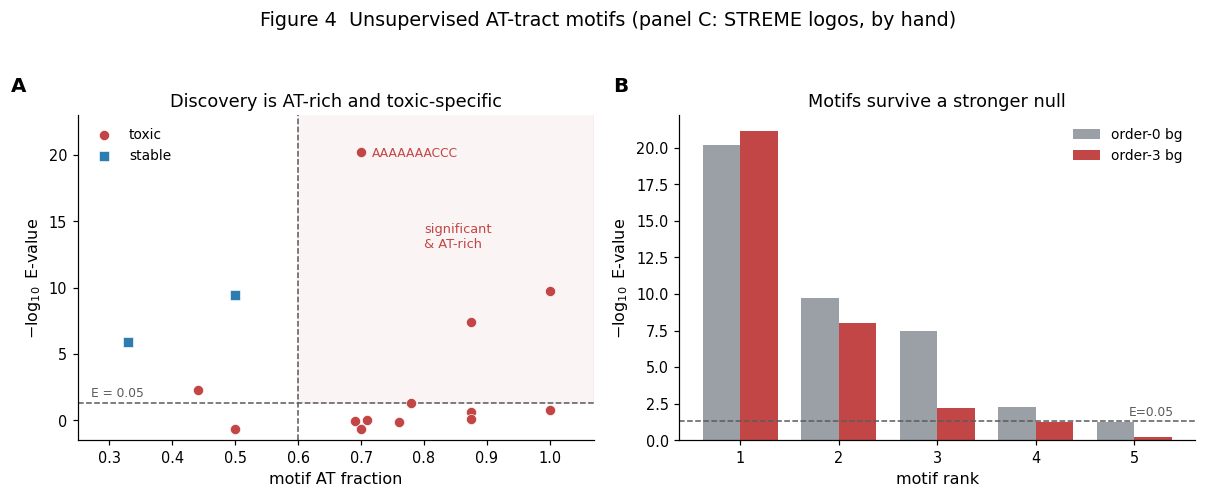

In [ ]:
#@title Figure 4 — unsupervised motifs (logos by hand)
from matplotlib.patches import Rectangle
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))

# 4A discovered-motif landscape: AT content vs significance, toxic vs stable
a = ax[0]
# primary discovery (order-0): (consensus AT fraction, E-value)
toxic = [(0.70, 6e-21, 'AAAAAAACCC'), (1.00, 1.8e-10, ''), (0.875, 3.6e-8, ''),
         (0.44, 5.2e-3, ''), (0.78, 5.3e-2, ''), (1.00, 1.8e-1, ''),
         (0.875, 2.3e-1, ''), (0.875, 7.4e-1, ''), (0.71, 1.0, ''),
         (0.69, 1.1, ''), (0.76, 1.4, ''), (0.50, 4.3, ''), (0.70, 4.3, '')]
stable = [(0.50, 3.4e-10), (0.33, 1.3e-6)]   # incl. order-3 stable motif
sig = -np.log10(0.05)
a.add_patch(Rectangle((0.6, sig), 0.47, 24, color=COL['comp'], alpha=0.06, zorder=0))
a.axhline(sig, ls='--', color=COL['ceil'], lw=1)
a.axvline(0.6, ls='--', color=COL['ceil'], lw=1)
tx = [p[0] for p in toxic]; ty = [-np.log10(p[1]) for p in toxic]
sx = [p[0] for p in stable]; sy = [-np.log10(p[1]) for p in stable]
a.scatter(tx, ty, s=44, color=COL['comp'], edgecolor='white', lw=0.4, label='toxic', zorder=3)
a.scatter(sx, sy, s=48, marker='s', color=COL['stable'], edgecolor='white', lw=0.4, label='stable', zorder=3)
a.annotate('AAAAAAACCC', (0.70, -np.log10(6e-21)), textcoords='offset points',
           xytext=(7, -3), fontsize=8, color=COL['comp'])
a.text(0.80, 13, 'significant\n& AT-rich', fontsize=8.5, color=COL['comp'])
a.text(0.27, sig + 0.5, 'E = 0.05', fontsize=8, color=COL['ceil'])
a.set_xlim(0.25, 1.07); a.set_ylim(-1.5, 23)
a.set_xlabel('motif AT fraction'); a.set_ylabel(r'$-\log_{10}$ E-value')
a.legend(frameon=False, loc='upper left')
a.set_title('Discovery is AT-rich and toxic-specific'); panel_letter(a, 'A')

# 4B order-0 vs order-3 survival (strong-null diagnostic)
b = ax[1]
o0 = [6e-21, 1.8e-10, 3.6e-8, 5.2e-3, 5.3e-2]
o3 = [6.8e-22, 9.7e-9, 5.9e-3, 5.9e-2, 5.6e-1]
idx = np.arange(1, 6); w = 0.38
b.bar(idx - w/2, [-np.log10(v) for v in o0], w, label='order-0 bg', color=COL['alt'])
b.bar(idx + w/2, [-np.log10(v) for v in o3], w, label='order-3 bg', color=COL['comp'])
b.axhline(-np.log10(0.05), color=COL['ceil'], ls='--', lw=1)
b.text(5.4, -np.log10(0.05) + 0.4, 'E=0.05', ha='right', fontsize=8, color=COL['ceil'])
b.set_xlabel('motif rank'); b.set_ylabel(r'$-\log_{10}$ E-value')
b.legend(frameon=False); b.set_title('Motifs survive a stronger null'); panel_letter(b, 'B')

fig.suptitle('Figure 4  Unsupervised AT-tract motifs (panel C: STREME logos, by hand)',
             y=1.02, fontsize=12.5)
fig.tight_layout()
save_fig(fig, 'Fig4_unsupervised_motifs')


saved /content/drive/MyDrive/Plasmids/figures/Fig5_convergence_and_null.png
[Fig 5 data sources]
  5C 3-mer-null table : live Cell 10c table  ->  0/6 enriched & q<0.05 under 3-mer null
  5D colocalisation   : live null histogram (COLOC_NPZ, n=1000)


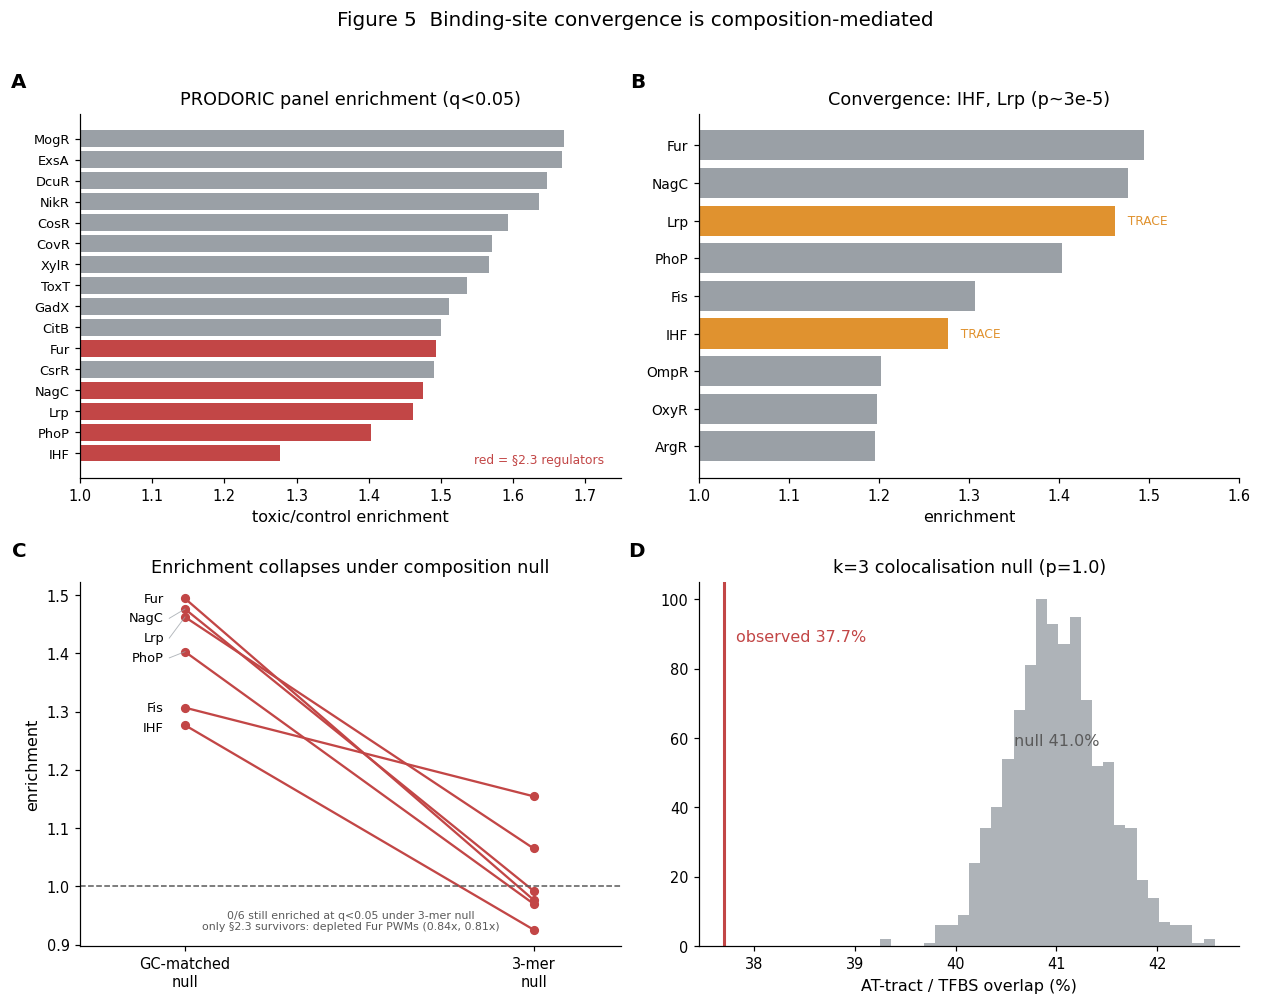

In [ ]:
#@title Figure 5 — TF convergence and composition null
fig, ax = plt.subplots(2, 2, figsize=(11.5, 9))

# 5A PRODORIC top enrichment (Cell 10b, verified)
a = ax[0, 0]
top = [('MogR', 1.671), ('ExsA', 1.668), ('DcuR', 1.648), ('NikR', 1.636),
       ('CosR', 1.594), ('CovR', 1.572), ('XylR', 1.567), ('ToxT', 1.536),
       ('GadX', 1.511), ('CitB', 1.500), ('Fur', 1.494), ('CsrR', 1.491),
       ('NagC', 1.476), ('Lrp', 1.462), ('IHF', 1.277), ('PhoP', 1.403)]
key = {'Fur', 'Lrp', 'IHF', 'PhoP', 'Fis', 'OmpR', 'OxyR', 'ArgR', 'NagC', 'CRP', 'NarL'}
top = sorted(top, key=lambda x: x[1])
names = [t[0] for t in top]; vals = [t[1] for t in top]
cols = [COL['comp'] if n in key else COL['alt'] for n in names]
a.barh(range(len(names)), vals, color=cols)
a.set_yticks(range(len(names))); a.set_yticklabels(names, fontsize=8.5)
a.set_xlim(1.0, 1.75); a.set_xlabel('toxic/control enrichment')
a.text(0.97, 0.04, 'red = §2.3 regulators', transform=a.transAxes, fontsize=8,
       ha='right', color=COL['comp'])
a.set_title('PRODORIC panel enrichment (q<0.05)'); panel_letter(a, 'A')

# 5B TRACE convergence (Cell 17, verified)
b = ax[0, 1]
conv = [('ArgR', 1.195, False), ('OxyR', 1.198, False), ('OmpR', 1.202, False),
        ('IHF', 1.277, True), ('Fis', 1.307, False), ('PhoP', 1.403, False),
        ('Lrp', 1.462, True), ('NagC', 1.476, False), ('Fur', 1.494, False)]
names = [c[0] for c in conv]; vals = [c[1] for c in conv]
cols = [COL['hi'] if c[2] else COL['alt'] for c in conv]
b.barh(range(len(names)), vals, color=cols)
for i, c in enumerate(conv):
    if c[2]:
        b.text(c[1]+0.005, i, '  TRACE', va='center', fontsize=8, color=COL['hi'])
b.set_yticks(range(len(names))); b.set_yticklabels(names, fontsize=9)
b.set_xlim(1.0, 1.6); b.set_xlabel('enrichment')
b.set_title('Convergence: IHF, Lrp (p~3e-5)'); panel_letter(b, 'B')

# 5C GC-null vs 3-mer-null collapse — values pulled from the real Cell 10c table
#     (enr_GC_null vs enrichment_vs_kmer3 for the headline PWM of each §2.3 TF).
#     Headline motif_ids match the Cell 10b/5A panel exactly.
c = ax[1, 0]
HEADLINE = [('Lrp', 'MX000096'), ('IHF', 'MX000028'), ('PhoP', 'MX000372'),
            ('Fur', 'MX000016'), ('NagC', 'MX000150'), ('Fis', 'MX000029')]
# verified fallback (Cell 10c: enr_GC_null, enrichment_vs_kmer3, q_kmer3)
FALLBACK = {'MX000096': (1.4623, 1.0651, 0.5954), 'MX000028': (1.2767, 0.9256, 0.3621),
            'MX000372': (1.4028, 0.9700, 0.5238), 'MX000016': (1.4941, 0.9767, 0.8132),
            'MX000150': (1.4761, 0.9922, 0.9765), 'MX000029': (1.3067, 1.1545, 0.3621)}
def _cell10c_table():
    g = load_globals()
    df = g.get('compare', None)
    if df is None:
        try:
            import pandas as pd
            df = pd.read_csv(f'{BASE}/streme_outputs/fimo_kmer3_null_comparison.csv')
        except Exception:
            df = None
    return df
_df = _cell10c_table()
pairs, n_enr_sig_k3, n_live_5c = [], 0, 0
for tf, mid in HEADLINE:
    gc = k3 = q = None; used_live = False
    if _df is not None and 'motif_id' in getattr(_df, 'columns', []):
        row = _df[_df['motif_id'] == mid]
        if len(row):
            gc = float(row['enr_GC_null'].iloc[0]); k3 = float(row['enrichment_vs_kmer3'].iloc[0])
            q = float(row['q_kmer3'].iloc[0]); used_live = True
    if gc is None or not np.isfinite(gc):
        gc, k3, q = FALLBACK[mid]; used_live = False
    pairs.append((tf, gc, k3)); n_live_5c += int(used_live)
    if (k3 > 1.0) and (q < 0.05):
        n_enr_sig_k3 += 1
src_5c = ('live Cell 10c table' if n_live_5c == len(HEADLINE)
          else 'verified FALLBACK dict' if n_live_5c == 0
          else f'mixed ({n_live_5c} live / {len(HEADLINE)-n_live_5c} fallback)')
for tf, gc, k3 in pairs:
    c.plot([0, 1], [gc, k3], '-o', color=COL['comp'], ms=5)
lab = sorted(pairs, key=lambda p: -p[1]); min_gap = 0.034; prev = None; ypos = {}
for tf, gc, k3 in lab:
    y = gc if prev is None else min(gc, prev - min_gap); ypos[tf] = y; prev = y
for tf, gc, k3 in pairs:
    if abs(ypos[tf] - gc) > 0.004:
        c.plot([-0.045, 0], [ypos[tf], gc], color=COL['alt'], lw=0.6, alpha=0.75)
    c.text(-0.06, ypos[tf], tf, ha='right', va='center', fontsize=8.5)
c.axhline(1.0, color=COL['ceil'], ls='--', lw=1)
c.set_xticks([0, 1]); c.set_xticklabels(['GC-matched\nnull', '3-mer\nnull'])
c.set_xlim(-0.30, 1.25); c.set_ylabel('enrichment')
c.text(0.5, 0.04, f'{n_enr_sig_k3}/6 still enriched at q<0.05 under 3-mer null\n'
       'only §2.3 survivors: depleted Fur PWMs (0.84x, 0.81x)',
       transform=c.transAxes, ha='center', va='bottom', fontsize=7.2, color=COL['ceil'])
c.set_title('Enrichment collapses under composition null'); panel_letter(c, 'C')

# 5D colocalisation null (Cell 13b/13c, verified: obs 37.7%, null ->41.0%, p=1.0)
d = ax[1, 1]
obs = 37.7
try:
    z = np.load(COLOC_NPZ)
    arr = z[z.files[0]]
    arr = arr[np.isfinite(arr)]
    d.hist(arr, bins=30, color=COL['alt'], alpha=0.8)
    src_5d = f'live null histogram (COLOC_NPZ, n={arr.size})'
except Exception:
    xs = np.linspace(38.5, 43.5, 400)
    g = np.exp(-0.5*((xs-41.0)/0.49)**2)
    d.fill_between(xs, g*120, color=COL['alt'], alpha=0.8)
    d.set_yticks([])
    src_5d = 'Gaussian approx (mean 41.0, sd 0.49) — COLOC_NPZ not found'
d.axvline(obs, color=COL['comp'], lw=2)
d.text(obs+0.12, d.get_ylim()[1]*0.85, 'observed 37.7%', ha='left', va='center', color=COL['comp'])
d.text(41.0, d.get_ylim()[1]*0.55, 'null 41.0%', ha='center', color=COL['ceil'])
d.set_xlabel('AT-tract / TFBS overlap (%)')
d.set_title('k=3 colocalisation null (p=1.0)'); panel_letter(d, 'D')

fig.suptitle('Figure 5  Binding-site convergence is composition-mediated', y=1.01, fontsize=13)
fig.tight_layout()
save_fig(fig, 'Fig5_convergence_and_null')

print('[Fig 5 data sources]')
print(f'  5C 3-mer-null table : {src_5c}  ->  {n_enr_sig_k3}/6 enriched & q<0.05 under 3-mer null')
print(f'  5D colocalisation   : {src_5d}')

saved /content/drive/MyDrive/Plasmids/figures/Fig6_single_axis.png
[Fig 6 data sources]
  6D positional track : verified hardcoded AT_DIFF vector (no fraction global in savepoint)
      degenerate-region mean toxic-stable AT fraction = +0.0212 (expect ~+0.021)
      peak +0.0664 at position 166; scars 1-4 / 169-172 masked to 0


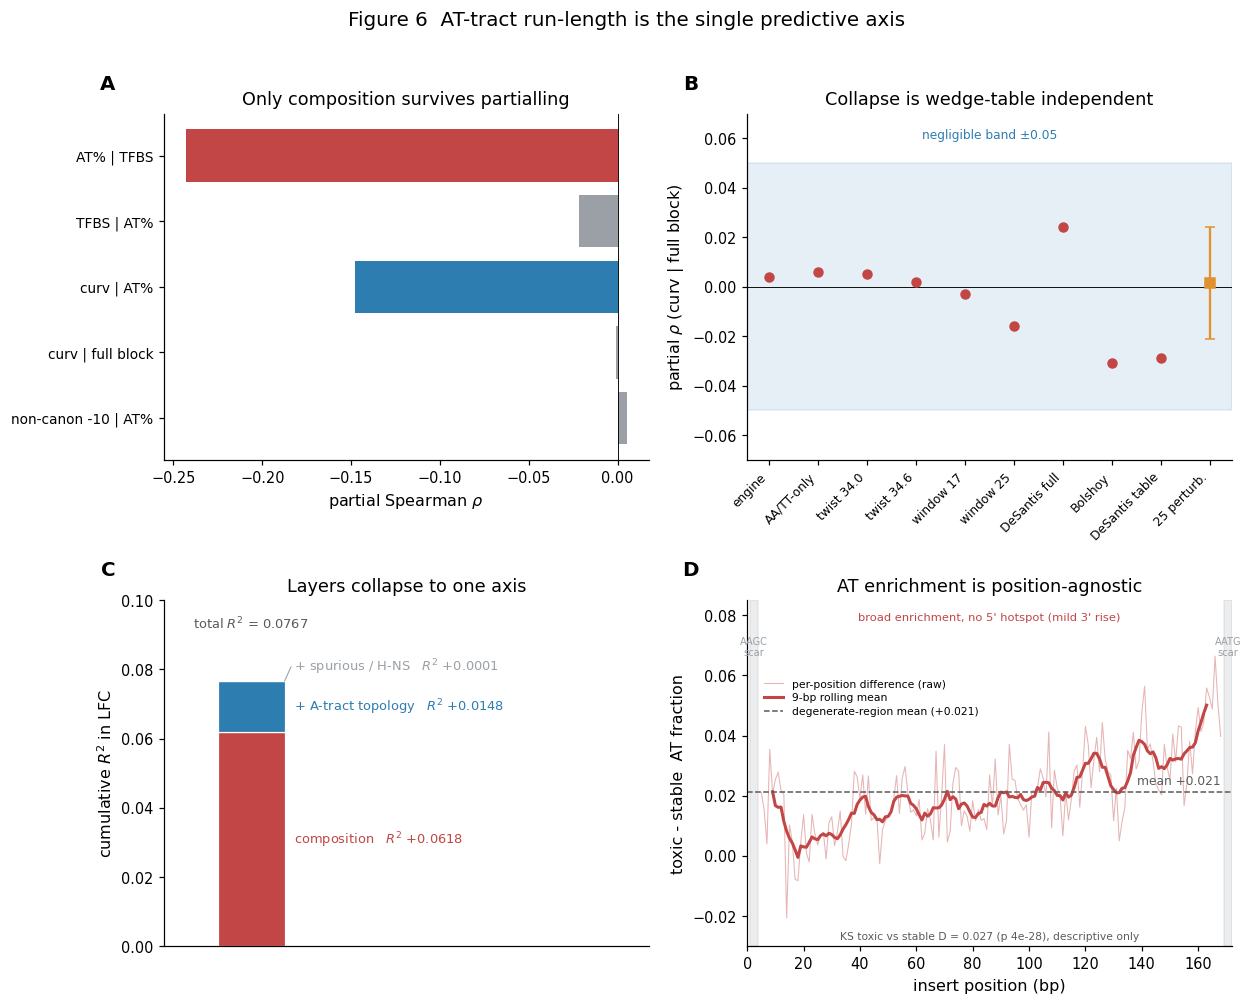

In [ ]:
#@title Figure 6 — single compositional axis
fig, ax = plt.subplots(2, 2, figsize=(11.5, 9))

# 6A partial-rho beyond composition (Cell 26 / 29b / 31g / 30b — all verified)
a = ax[0, 0]
items = [('AT% | TFBS', -0.243, COL['comp']), ('TFBS | AT%', -0.022, COL['alt']),
         ('curv | AT%', -0.148, COL['stable']), ('curv | full block', -0.001, COL['alt']),
         ('non-canon -10 | AT%', 0.005, COL['alt'])]   # Cell 30b: +0.005 (was -0.010)
names = [i[0] for i in items]; vals = [i[1] for i in items]; cols = [i[2] for i in items]
a.barh(range(len(names)), vals, color=cols)
a.axvline(0, color='k', lw=0.6)
a.set_yticks(range(len(names))); a.set_yticklabels(names, fontsize=9)
a.invert_yaxis(); a.set_xlabel(r'partial Spearman $\rho$')
a.set_title('Only composition survives partialling'); panel_letter(a, 'A')

# 6B curvature robustness across configs (Cell 29d, verified)
b = ax[0, 1]
cfg = [('engine', 0.004), ('AA/TT-only', 0.006), ('twist 34.0', 0.005),
       ('twist 34.6', 0.002), ('window 17', -0.003), ('window 25', -0.016),
       ('DeSantis full', 0.024), ('Bolshoy', -0.031), ('DeSantis table', -0.029)]
b.axhspan(-0.05, 0.05, color=COL['stable'], alpha=0.12)
b.axhline(0, color='k', lw=0.6)
b.scatter(range(len(cfg)), [c[1] for c in cfg], color=COL['comp'], zorder=3, s=34)
b.errorbar(len(cfg), 0.0015, yerr=[[0.0015+0.021], [0.024-0.0015]], fmt='s',
           color=COL['hi'], capsize=3)
labs = [c[0] for c in cfg] + ['25 perturb.']
b.set_xticks(range(len(cfg)+1)); b.set_xticklabels(labs, rotation=45, ha='right', fontsize=8)
b.set_ylim(-0.07, 0.07); b.set_ylabel(r'partial $\rho$ (curv | full block)')
b.text(0.5, 0.93, 'negligible band ±0.05', transform=b.transAxes, ha='center',
       fontsize=8, color=COL['stable'])
b.set_title('Collapse is wedge-table independent'); panel_letter(b, 'B')

# 6C nested-layer stacked bar (Cell 31f, verified)
c = ax[1, 0]
seg = [('composition', 0.0618, COL['comp']),
       ('+ A-tract topology', 0.0148, COL['stable']),
       ('+ spurious / H-NS', 0.0001, COL['alt'])]
xb, bw, bottom = 0.0, 0.42, 0.0
mids = []
for name, h, col in seg:
    c.bar(xb, h, bottom=bottom, width=bw, color=col, edgecolor='white', linewidth=0.8)
    mids.append((name, bottom + h/2, h, col)); bottom += h
xr = xb + bw/2 + 0.06
for name, ymid, h, col in mids:
    lab = f'{name}   $R^2$ +{h:.4f}'
    if h < 0.003:
        ytext = bottom + 0.004
        c.plot([xb + bw/2, xr - 0.02], [ymid, ytext], color=col, lw=0.7)
        c.text(xr, ytext, lab, va='center', fontsize=8.5, color=col)
    else:
        c.text(xr, ymid, lab, va='center', fontsize=8.5, color=col)
c.text(xb, bottom + 0.015, f'total $R^2$ = {bottom:.4f}', ha='center',
       fontsize=8.5, color=COL['ceil'])
c.set_xlim(-0.55, 2.5); c.set_ylim(0, 0.10); c.set_xticks([])
c.set_ylabel(r'cumulative $R^2$ in LFC')
c.set_title('Layers collapse to one axis'); panel_letter(c, 'C')

# 6D position-agnostic AT-tract enrichment (toxic - stable AT FRACTION, per position).
#     Live path: a saved 172-vector of the per-position toxic-stable AT-fraction
#     difference (g['at_fraction_diff'], or g['toxic_at_frac']-g['stable_at_frac']).
#     Fallback: the verified hardcoded vector below (derived from the 124,339-variant
#     GGS3 library; toxic = lowest-9,215 LFC, stable = 9,215 nearest zero).
#     This is the FRACTION difference (uniform ~+0.02), NOT AT-tract coverage; the
#     coverage metric manufactures apparent 5'/3' hotspots via the baseline T-bias x
#     run-length threshold and is intentionally not used here.
d = ax[1, 1]
pos = np.arange(1, 173)
AT_DIFF = np.array([0.0000, 0.0000, 0.0000, 0.0000, 0.0211, 0.0153, 0.0040, 0.0355, 0.0208, 0.0254, 0.0278, 0.0217, 0.0204, -0.0206, 0.0103, 0.0047, -0.0078, -0.0082, 0.0044, 0.0137, 0.0010, -0.0020, 0.0138, 0.0074, 0.0036, 0.0069, 0.0078, -0.0010, 0.0110, 0.0130, 0.0034, 0.0080, 0.0149, -0.0002, -0.0016, 0.0039, 0.0107, 0.0281, 0.0263, 0.0191, 0.0269, 0.0139, 0.0266, 0.0118, 0.0127, 0.0129, -0.0026, 0.0087, 0.0117, 0.0129, 0.0147, 0.0191, 0.0267, 0.0141, 0.0259, 0.0297, 0.0208, 0.0145, 0.0153, 0.0133, 0.0187, 0.0053, 0.0076, 0.0157, 0.0119, 0.0053, 0.0348, 0.0062, 0.0203, 0.0370, 0.0046, 0.0082, 0.0243, 0.0294, 0.0282, 0.0100, 0.0150, 0.0132, 0.0082, 0.0184, 0.0117, 0.0154, 0.0118, 0.0124, 0.0087, 0.0269, 0.0165, 0.0322, 0.0136, 0.0199, 0.0073, 0.0117, 0.0371, 0.0255, 0.0251, 0.0190, 0.0171, 0.0152, 0.0170, 0.0062, 0.0216, 0.0216, 0.0228, 0.0289, 0.0258, 0.0196, 0.0412, 0.0093, 0.0285, 0.0225, 0.0201, 0.0067, 0.0212, 0.0120, 0.0188, 0.0282, 0.0302, 0.0162, 0.0282, 0.0431, 0.0370, 0.0227, 0.0319, 0.0394, 0.0280, 0.0443, 0.0323, 0.0280, 0.0268, 0.0117, 0.0225, 0.0050, 0.0115, 0.0162, 0.0351, 0.0323, 0.0411, 0.0289, 0.0315, 0.0476, 0.0564, 0.0355, 0.0372, 0.0313, 0.0240, 0.0218, 0.0203, 0.0370, 0.0294, 0.0253, 0.0405, 0.0313, 0.0432, 0.0428, 0.0167, 0.0241, 0.0381, 0.0273, 0.0413, 0.0493, 0.0413, 0.0445, 0.0558, 0.0528, 0.0488, 0.0664, 0.0507, 0.0397, 0.0000, 0.0000, 0.0000, 0.0000])
assert AT_DIFF.size == 172, f'AT_DIFF must be 172, got {AT_DIFF.size}'

g = load_globals()
diff = None; src_6d = None
_cand = g.get('at_fraction_diff', None)
if _cand is not None and np.ravel(_cand).size == 172:
    diff = np.asarray(_cand, float).ravel(); src_6d = "live g['at_fraction_diff']"
else:
    _tf = g.get('toxic_at_frac', None); _sf = g.get('stable_at_frac', None)
    if (_tf is not None and _sf is not None
            and np.ravel(_tf).size == 172 and np.ravel(_sf).size == 172):
        diff = np.asarray(_tf, float).ravel() - np.asarray(_sf, float).ravel()
        src_6d = "live g['toxic_at_frac'] - g['stable_at_frac']"
if diff is None:
    diff = AT_DIFF.copy(); src_6d = 'verified hardcoded AT_DIFF vector (no fraction global in savepoint)'

# mask constant cloning scars (1-4 AAGC, 169-172 AATG): zero by construction
diff = diff.copy(); diff[:4] = 0.0; diff[168:] = 0.0
deg = slice(4, 168)                                  # positions 5..168, degenerate region
mean_diff = float(diff[deg].mean())                  # expect ~+0.021
peak_pos = int(pos[deg][np.argmax(diff[deg])]); peak_val = float(diff[deg].max())

d.plot(pos[deg], diff[deg], color=COL['comp'], lw=0.7, alpha=0.40,
       label='per-position difference (raw)')
k = 9
sm = np.convolve(diff[deg], np.ones(k) / k, mode='same')
d.plot(pos[deg][k // 2:-k // 2], sm[k // 2:-k // 2], color=COL['comp'], lw=2.0,
       label='9-bp rolling mean')
d.axhline(mean_diff, color=COL['ceil'], lw=1.0, ls='--',
          label=f'degenerate-region mean (+{mean_diff:.3f})')
d.text(168, mean_diff + 0.0015, f'mean +{mean_diff:.3f}', ha='right', va='bottom',
       fontsize=8, color=COL['ceil'])
for lo, hi in [(1, 4), (169, 172)]:                  # constant scars, masked
    d.axvspan(lo, hi, color=COL['alt'], alpha=0.18)
d.set_ylim(-0.03, 0.085); d.set_xlim(0, 172)
d.text(2.5, 0.073, 'AAGC\nscar', ha='center', va='top', fontsize=6.5, color=COL['alt'])
d.text(170.5, 0.073, 'AATG\nscar', ha='center', va='top', fontsize=6.5, color=COL['alt'])
d.text(0.5, 0.965, "broad enrichment, no 5' hotspot (mild 3' rise)", transform=d.transAxes,
       ha='center', va='top', fontsize=7.5, color=COL['comp'])
d.text(0.5, 0.02, 'KS toxic vs stable D = 0.027 (p 4e-28), descriptive only',
       transform=d.transAxes, ha='center', fontsize=7, color=COL['ceil'])
d.legend(loc='upper left', bbox_to_anchor=(0.015, 0.80), fontsize=7, frameon=True,
         framealpha=0.85, edgecolor='none', handlelength=1.8, borderpad=0.4, labelspacing=0.35)
d.set_xlabel('insert position (bp)'); d.set_ylabel('toxic - stable  AT fraction')
d.set_title('AT enrichment is position-agnostic'); panel_letter(d, 'D')

fig.suptitle('Figure 6  AT-tract run-length is the single predictive axis', y=1.01, fontsize=13)
fig.tight_layout()
save_fig(fig, 'Fig6_single_axis')

print('[Fig 6 data sources]')
print(f'  6D positional track : {src_6d}')
print(f'      degenerate-region mean toxic-stable AT fraction = +{mean_diff:.4f} (expect ~+0.021)')
print(f'      peak +{peak_val:.4f} at position {peak_pos}; scars 1-4 / 169-172 masked to 0')

saved /content/drive/MyDrive/Plasmids/figures/Fig7_host_and_transfer.png


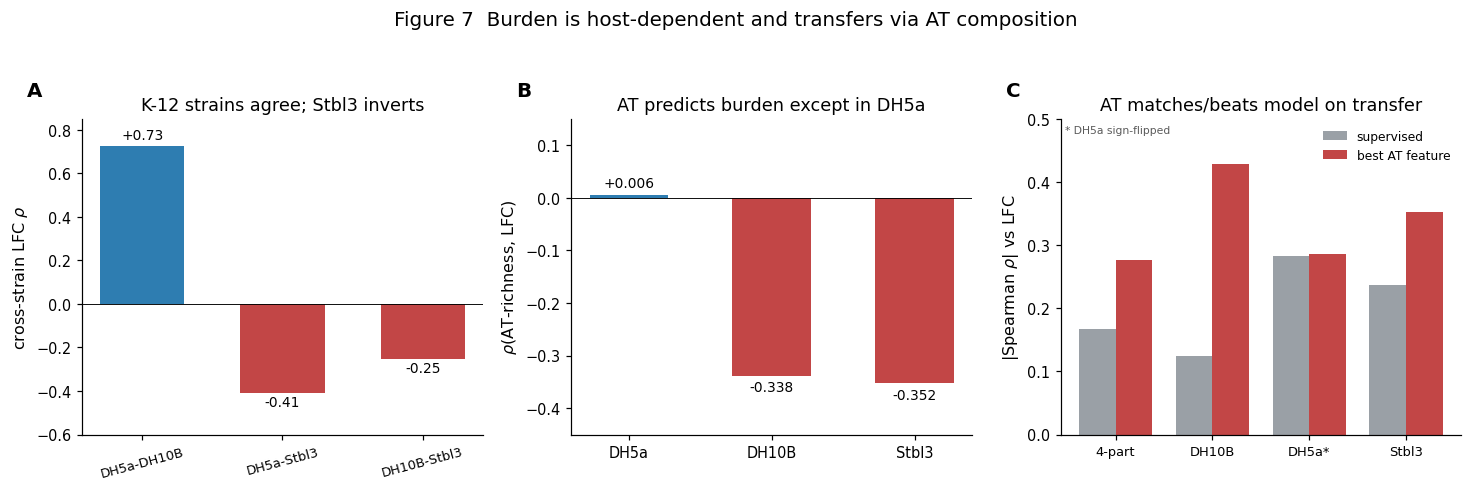

In [ ]:
#@title Figure 7 — host dependence and length transfer
fig, ax = plt.subplots(1, 3, figsize=(13.5, 4.3))

# 7A cross-strain pairwise
a = ax[0]
pairs = ['DH5a-DH10B', 'DH5a-Stbl3', 'DH10B-Stbl3']
vals = [0.727, -0.411, -0.253]
a.bar(pairs, vals, color=[COL['stable'] if v > 0 else COL['comp'] for v in vals], width=0.6)
a.axhline(0, color='k', lw=0.6); a.set_ylabel(r'cross-strain LFC $\rho$'); a.set_ylim(-0.6, 0.85)
for i, v in enumerate(vals):
    a.text(i, v + (0.03 if v > 0 else -0.06), f'{v:+.2f}', ha='center', fontsize=9)
a.set_xticklabels(pairs, rotation=15, fontsize=8.5)
a.set_title('K-12 strains agree; Stbl3 inverts'); panel_letter(a, 'A')

# 7B DH5a AT inversion
b = ax[1]
strains = ['DH5a', 'DH10B', 'Stbl3']
rho_at = [0.006, -0.338, -0.352]
b.bar(strains, rho_at, color=[COL['stable'] if v >= 0 else COL['comp'] for v in rho_at], width=0.55)
b.axhline(0, color='k', lw=0.6); b.set_ylabel(r'$\rho$(AT-richness, LFC)'); b.set_ylim(-0.45, 0.15)
for i, v in enumerate(rho_at):
    b.text(i, v + (0.015 if v >= 0 else -0.03), f'{v:+.3f}', ha='center', fontsize=9)
b.set_title('AT predicts burden except in DH5a'); panel_letter(b, 'B')

# 7C cross-length transfer: supervised vs best AT feature (|rho|)
c = ax[2]
tiers = ['4-part', 'DH10B', 'DH5a*', 'Stbl3']
sup = [0.167, 0.124, 0.282, 0.237]
at_ = [0.276, 0.429, 0.286, 0.352]
x = np.arange(len(tiers)); w = 0.38
c.bar(x - w/2, sup, w, label='supervised', color=COL['alt'])
c.bar(x + w/2, at_, w, label='best AT feature', color=COL['comp'])
c.set_xticks(x); c.set_xticklabels(tiers, fontsize=8.5)
c.set_ylabel(r'|Spearman $\rho$| vs LFC'); c.set_ylim(0, 0.5)
c.legend(frameon=False, fontsize=8, loc='upper right')
c.text(0.01, 0.98, '* DH5a sign-flipped', transform=c.transAxes, ha='left', va='top', fontsize=7, color=COL['ceil'])
c.set_title('AT matches/beats model on transfer'); panel_letter(c, 'C')

fig.suptitle('Figure 7  Burden is host-dependent and transfers via AT composition', y=1.03, fontsize=13)
fig.tight_layout()
save_fig(fig, 'Fig7_host_and_transfer')

saved /content/drive/MyDrive/Plasmids/figures/Fig8_feature_attribution.png


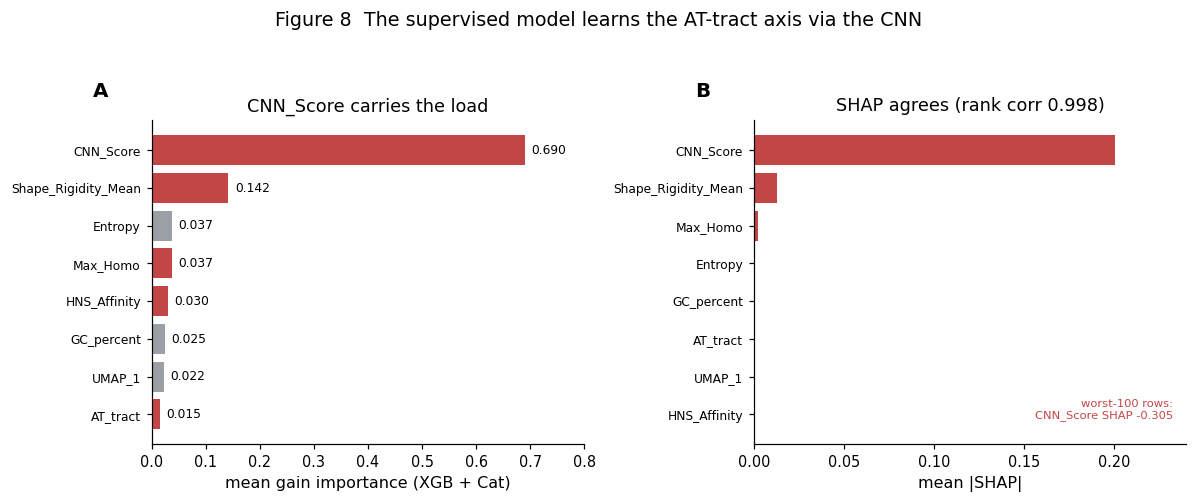

In [ ]:
#@title Figure 8 — supervised feature attribution
fig, ax = plt.subplots(1, 2, figsize=(11, 4.4))
EMPH = {'CNN_Score', 'Shape_Rigidity_Mean', 'Max_Homo', 'AT_tract', 'HNS_Affinity'}

# 8A gain importance (Cell 23d)
a = ax[0]
imp = [('CNN_Score', 0.690), ('Shape_Rigidity_Mean', 0.142), ('Entropy', 0.0375),
       ('Max_Homo', 0.0373), ('HNS_Affinity', 0.0305), ('GC_percent', 0.0247),
       ('UMAP_1', 0.0223), ('AT_tract', 0.0151)]
imp = sorted(imp, key=lambda x: x[1])
names = [i[0] for i in imp]; vals = [i[1] for i in imp]
a.barh(range(len(names)), vals, color=[COL['comp'] if n in EMPH else COL['alt'] for n in names])
for i, v in enumerate(vals):
    a.text(v + 0.012, i, f'{v:.3f}', va='center', fontsize=8)
a.set_yticks(range(len(names))); a.set_yticklabels(names, fontsize=8)
a.set_xlim(0, 0.80); a.set_xlabel('mean gain importance (XGB + Cat)')
a.set_title('CNN_Score carries the load'); panel_letter(a, 'A')

# 8B SHAP (Cell 23m)
b = ax[1]
sh = [('CNN_Score', 0.2004), ('Shape_Rigidity_Mean', 0.0127), ('Max_Homo', 0.0025),
      ('Entropy', 0.0004), ('GC_percent', 0.0002), ('HNS_Affinity', 0.0001),
      ('UMAP_1', 0.0001), ('AT_tract', 0.0001)]
sh = sorted(sh, key=lambda x: x[1])
names = [s[0] for s in sh]; vals = [s[1] for s in sh]
b.barh(range(len(names)), vals, color=[COL['comp'] if n in EMPH else COL['alt'] for n in names])
b.set_yticks(range(len(names))); b.set_yticklabels(names, fontsize=8)
b.set_xlim(0, 0.24); b.set_xlabel('mean |SHAP|')
b.text(0.97, 0.08, 'worst-100 rows:\nCNN_Score SHAP -0.305', transform=b.transAxes,
       ha='right', fontsize=7.5, color=COL['comp'])
b.set_title('SHAP agrees (rank corr 0.998)'); panel_letter(b, 'B')

fig.suptitle('Figure 8  The supervised model learns the AT-tract axis via the CNN', y=1.03, fontsize=12.5)
fig.tight_layout()
save_fig(fig, 'Fig8_feature_attribution')


[panelA] using verified hardcoded Cell 25b values
[panelB] using verified hardcoded Cell 25c values

Saved: figure_ablation_ATvsGC.png
Panel A: full 0.5331 | run 0.5241 | bulk 0.4024 | run+bulk 0.5304
Panel B AT: [0.5331, 0.5475, 0.4047]
Panel B GC: [0.4601, 0.4843, 0.3328]


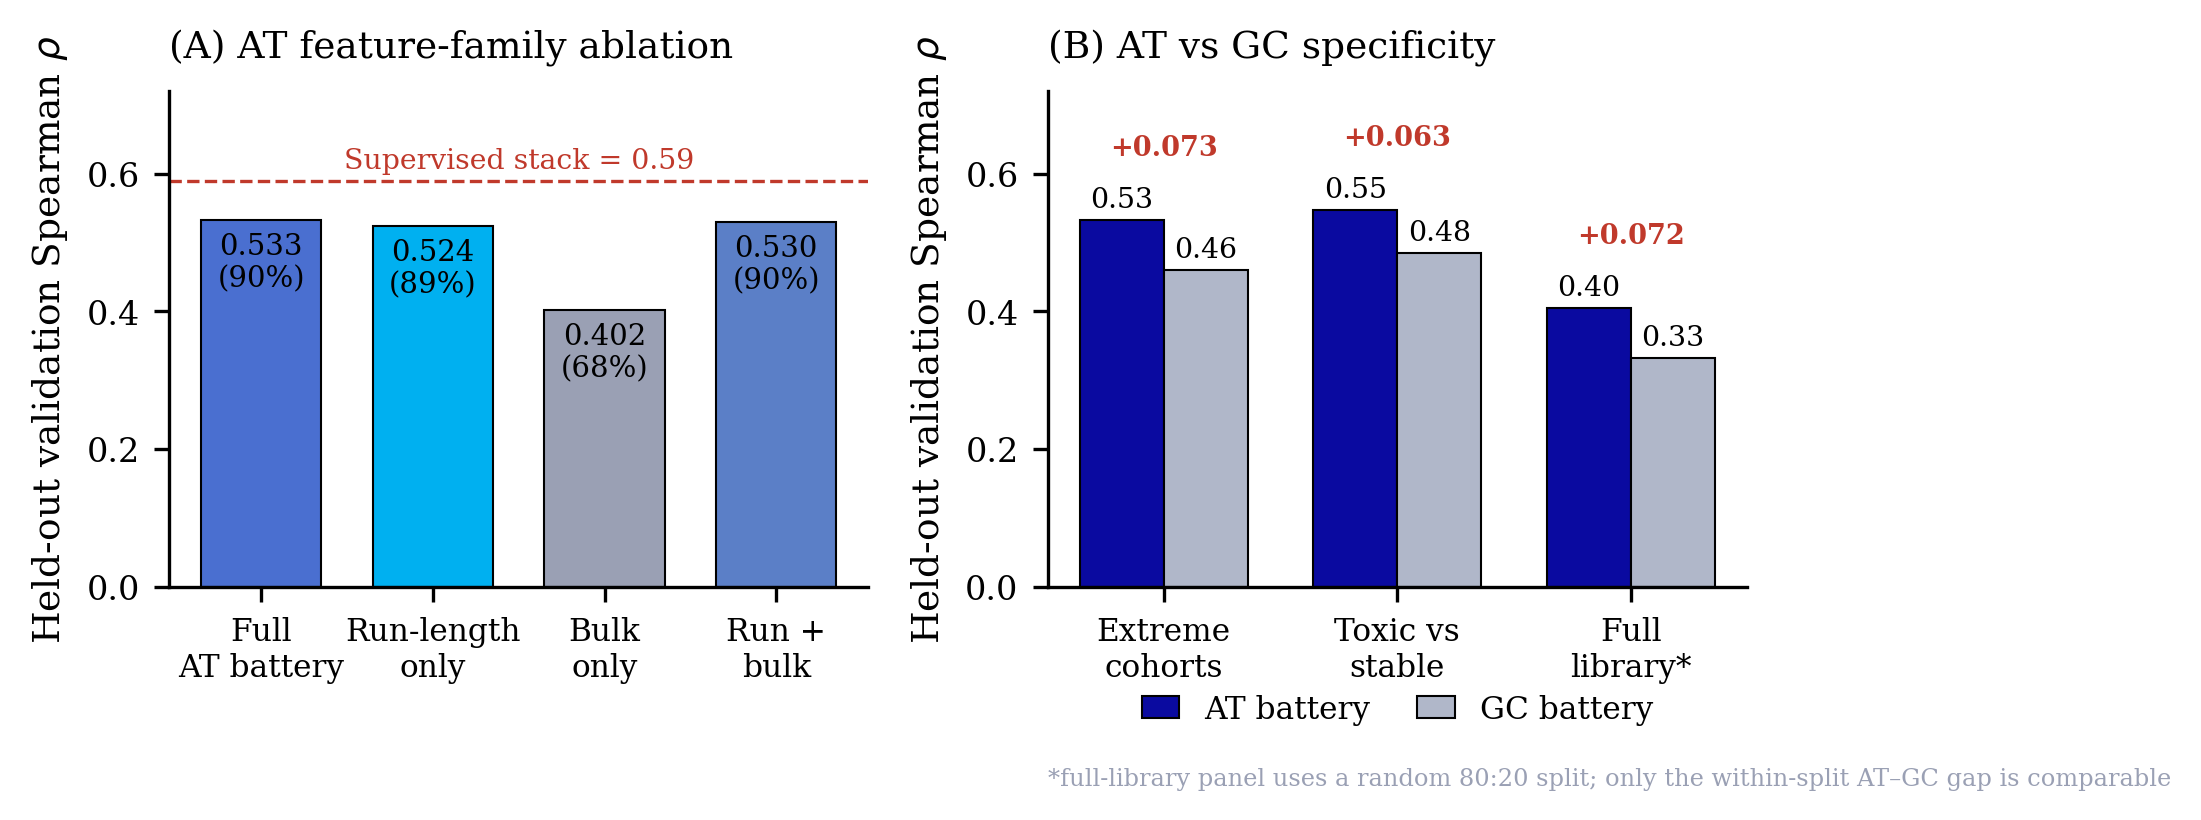

In [ ]:
# =====================================================================
# Phase 3 figure - AT-feature-family ablation + AT-vs-GC specificity
# =====================================================================
# Plots results already computed by Cell 25b (at_family_ablation) and
# Cell 25c (gc_vs_at). NO new computation: uses the saved globals if
# present, else the verified hardcoded values from those runs.
# Two-panel figure for Results 4.5 (suggested Figure 3E/F or Figure 9).

import numpy as np, matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    'font.family': 'serif', 'font.size': 9, 'axes.linewidth': 0.8,
    'xtick.labelsize': 8, 'ytick.labelsize': 8, 'axes.labelsize': 9,
    'legend.fontsize': 7.5, 'figure.dpi': 300,
})
NAVY, CYAN, GREY, RED = '#0A0AA0', '#00B0F0', '#9AA0B4', '#C0392B'
STACK = 0.5895

# ---- Panel A data: from Cell 25b (at_family_ablation) ----
if 'at_family_ablation' in globals():
    _a = globals()['at_family_ablation'].set_index('subset')['val_rho']
    A_full = float(_a.get('full_battery', 0.5331)); A_run = float(_a.get('run_only', 0.5241))
    A_bulk = float(_a.get('bulk_only', 0.4024));    A_rb  = float(_a.get('run+bulk', 0.5304))
    print("[panelA] using at_family_ablation from session")
else:
    A_full, A_run, A_bulk, A_rb = 0.5331, 0.5241, 0.4024, 0.5304
    print("[panelA] using verified hardcoded Cell 25b values")

# ---- Panel B data: from Cell 25c (gc_vs_at) ----
if 'gc_vs_at' in globals():
    _g = globals()['gc_vs_at']
    at_vals = _g['at_rho'].tolist(); gc_vals = _g['gc_rho'].tolist()
    if len(at_vals) >= 3:
        AT_B = [at_vals[0], at_vals[1], at_vals[-1]]
        GC_B = [gc_vals[0], gc_vals[1], gc_vals[-1]]
    else:
        AT_B, GC_B = [0.5331, 0.5475, 0.4047], [0.4601, 0.4843, 0.3328]
    print("[panelB] using gc_vs_at from session")
else:
    AT_B = [0.5331, 0.5475, 0.4047]
    GC_B = [0.4601, 0.4843, 0.3328]
    print("[panelB] using verified hardcoded Cell 25c values")

# extra vertical headroom so nothing collides with the top
YMAX = 0.72
fig, (axA, axB) = plt.subplots(1, 2, figsize=(7.2, 3.1))

# ===== Panel A: family ablation =====
labelsA = ['Full\nAT battery', 'Run-length\nonly', 'Bulk\nonly', 'Run +\nbulk']
valsA   = [A_full, A_run, A_bulk, A_rb]
colsA   = ['#4A6FD0', CYAN, GREY, '#5B7FC7']
axA.bar(range(4), valsA, color=colsA, edgecolor='black', linewidth=0.5, width=0.7)
# stack reference line + label placed in the clear headroom band, RIGHT side, above the run+bulk bar gap
axA.axhline(STACK, ls='--', lw=0.8, color=RED)
axA.text(1.5, STACK + 0.010, f'Supervised stack = {STACK:.2f}', color=RED,
         fontsize=6.8, ha='center', va='bottom')
for i, v in enumerate(valsA):
    # value labels INSIDE the top of each bar, so the stack line never cuts through them
    axA.text(i, v - 0.018, f'{v:.3f}\n({100*v/STACK:.0f}%)', ha='center', va='top',
             fontsize=7, color='black')
axA.set_xticks(range(4)); axA.set_xticklabels(labelsA, fontsize=7.5)
axA.set_ylabel('Held-out validation Spearman $\\rho$')
axA.set_ylim(0, YMAX); axA.set_title('(A) AT feature-family ablation', fontsize=9, loc='left', pad=8)
axA.spines[['top', 'right']].set_visible(False)

# ===== Panel B: AT vs GC across cohorts =====
cohorts = ['Extreme\ncohorts', 'Toxic vs\nstable', 'Full\nlibrary*']
x = np.arange(3); w = 0.36
axB.bar(x - w/2, AT_B, w, color=NAVY, edgecolor='black', linewidth=0.5, label='AT battery')
axB.bar(x + w/2, GC_B, w, color='#B0B7C9', edgecolor='black', linewidth=0.5, label='GC battery')
for i in range(3):
    # value labels sit just above each bar
    axB.text(x[i]-w/2, AT_B[i]+0.010, f'{AT_B[i]:.2f}', ha='center', va='bottom', fontsize=6.8)
    axB.text(x[i]+w/2, GC_B[i]+0.010, f'{GC_B[i]:.2f}', ha='center', va='bottom', fontsize=6.8)
    # red gap label lifted well above the taller bar's value label, into the headroom
    top = max(AT_B[i], GC_B[i])
    axB.text(x[i], top + 0.085, f'+{AT_B[i]-GC_B[i]:.3f}', ha='center', va='bottom',
             fontsize=6.5, color=RED, fontweight='bold')
axB.set_xticks(x); axB.set_xticklabels(cohorts, fontsize=7.5)
axB.set_ylabel('Held-out validation Spearman $\\rho$')
axB.set_ylim(0, YMAX); axB.set_title('(B) AT vs GC specificity', fontsize=9, loc='left', pad=8)
# legend placed OUTSIDE the axes, below, horizontal - never overlaps bars
axB.legend(loc='upper center', frameon=False, ncol=2, bbox_to_anchor=(0.5, -0.16),
           handlelength=1.2, columnspacing=1.5)
axB.spines[['top', 'right']].set_visible(False)
axB.text(0.0, -0.40, '*full-library panel uses a random 80:20 split; only the within-split AT\u2013GC gap is comparable',
         transform=axB.transAxes, fontsize=5.8, color=GREY, ha='left')

plt.tight_layout()
OUT = 'figure_ablation_ATvsGC.png'
plt.savefig(OUT, bbox_inches='tight', dpi=300)
print(f"\nSaved: {OUT}")
print(f"Panel A: full {A_full:.4f} | run {A_run:.4f} | bulk {A_bulk:.4f} | run+bulk {A_rb:.4f}")
print(f"Panel B AT: {[round(v,4) for v in AT_B]}")
print(f"Panel B GC: {[round(v,4) for v in GC_B]}")
plt.show()

In [ ]:
print('All figures written to', OUTDIR)


All figures written to /content/drive/MyDrive/Plasmids/figures


saved


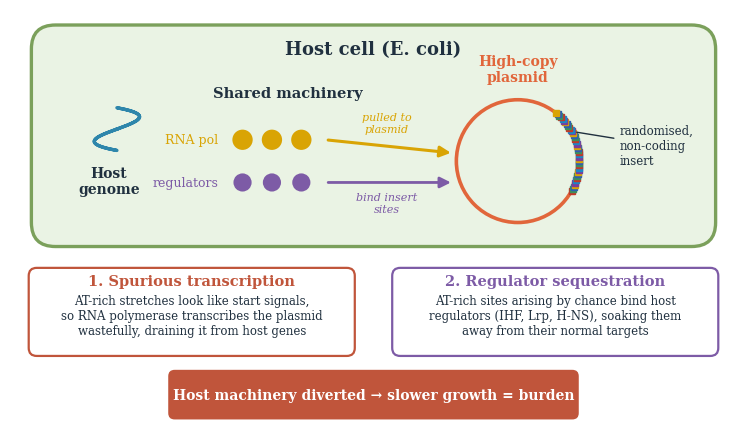

In [ ]:
# =====================================================================
# FIGURE 1 - How a randomised, non-coding plasmid insert imposes burden
# Compact single-column version: bigger text, less dead space.
# Colab-runnable. Place in INTRODUCTION, after "...called burden [1]."
# =====================================================================
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
import matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'serif','font.size':11})
CELL='#EAF3E4'; CELL_ED='#7BA05B'; TEAL='#2E86AB'; ORANGE='#E1663B'; NAVY='#20303F'
GREY='#5A6472'; RED='#C0553B'; GOLD='#D9A404'; PURPLE='#7D5BA6'

fig, ax = plt.subplots(figsize=(7.6, 4.6)); ax.set_xlim(0,13.6); ax.set_ylim(2.2,10.2); ax.axis('off')

# ---- host cell body (tighter) ----
ax.add_patch(FancyBboxPatch((0.4,5.75),12.8,4.15,boxstyle="round,pad=0,rounding_size=0.45",
                            fc=CELL,ec=CELL_ED,lw=2.4,zorder=0))
ax.text(6.8,9.35,"Host cell (E. coli)",ha='center',fontsize=13,fontweight='bold',color=NAVY,zorder=5)

def arrow(x1,y1,x2,y2,c=GREY,lw=2.0):
    ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle='-|>',mutation_scale=16,lw=lw,color=c,zorder=4))

# ===== LEFT: host genome =====
th=np.linspace(0,2*np.pi,200)
ax.plot(2.0+0.55*np.sin(2*th)*np.cos(th), 7.95+0.4*np.sin(th), color=TEAL, lw=2.4, zorder=2)
ax.text(1.85,6.75,"Host\ngenome",ha='center',fontsize=10,color=NAVY,fontweight='bold',zorder=4)

# ===== CENTER: shared machinery =====
ax.text(5.2,8.55,"Shared machinery",ha='center',fontsize=10.5,color=NAVY,fontweight='bold',zorder=4)
for x in [4.35,4.9,5.45]: ax.add_patch(Circle((x,7.75),0.19,fc=GOLD,ec='none',zorder=3))
ax.text(3.9,7.75,"RNA pol",ha='right',va='center',fontsize=9,color=GOLD,zorder=4)
for x in [4.35,4.9,5.45]: ax.add_patch(Circle((x,6.95),0.17,fc=PURPLE,ec='none',zorder=3))
ax.text(3.9,6.95,"regulators",ha='right',va='center',fontsize=9,color=PURPLE,zorder=4)

# ===== RIGHT: plasmid with randomised insert =====
pc=(9.5,7.35)
ax.add_patch(Circle(pc,1.15,fc='none',ec=ORANGE,lw=2.6,zorder=2))
ax.text(pc[0],pc[1]+1.5,"High-copy\nplasmid",ha='center',fontsize=10,color=ORANGE,fontweight='bold',zorder=4)
seg=np.linspace(-0.5,0.9,40); cols=['#C0392B','#3E8E5A','#2E5FB0','#D9A404','#7D3C98','#1C86C6']
for k,a in enumerate(seg):
    ax.plot([pc[0]+1.15*np.cos(a)],[pc[1]+1.15*np.sin(a)],marker='s',ms=4.0,color=cols[k%len(cols)],zorder=3)
ax.annotate('randomised,\nnon-coding\ninsert', xy=(pc[0]+1.05,pc[1]+0.55), xytext=(pc[0]+1.9,pc[1]+0.3),
            fontsize=8.5,color=NAVY,ha='left',va='center',zorder=6,
            arrowprops=dict(arrowstyle='-',color=NAVY,lw=1.0))

# transfer arrows (start right of dots at x~5.8, reach plasmid at x~8.25)
arrow(5.9,7.75,8.3,7.5,c=GOLD,lw=2.2)
ax.text(7.05,7.9,"pulled to\nplasmid",ha='center',fontsize=8,color=GOLD,style='italic',zorder=5)
arrow(5.9,6.95,8.3,6.95,c=PURPLE,lw=2.0)
ax.text(7.05,6.4,"bind insert\nsites",ha='center',fontsize=8,color=PURPLE,style='italic',zorder=5)

# ===== two mechanism boxes (below the cell, bigger text) =====
ax.add_patch(FancyBboxPatch((0.4,3.75),6.0,1.55,boxstyle="round,pad=0.05,rounding_size=0.15",fc='white',ec=RED,lw=1.6,zorder=2))
ax.text(3.4,5.02,"1. Spurious transcription",ha='center',fontsize=10.5,fontweight='bold',color=RED,zorder=3)
ax.text(3.4,4.12,"AT-rich stretches look like start signals,\nso RNA polymerase transcribes the plasmid\nwastefully, draining it from host genes",ha='center',fontsize=8.5,color=NAVY,zorder=3)

ax.add_patch(FancyBboxPatch((7.2,3.75),6.0,1.55,boxstyle="round,pad=0.05,rounding_size=0.15",fc='white',ec=PURPLE,lw=1.6,zorder=2))
ax.text(10.2,5.02,"2. Regulator sequestration",ha='center',fontsize=10.5,fontweight='bold',color=PURPLE,zorder=3)
ax.text(10.2,4.12,"AT-rich sites arising by chance bind host\nregulators (IHF, Lrp, H-NS), soaking them\naway from their normal targets",ha='center',fontsize=8.5,color=NAVY,zorder=3)

# result banner (bigger)
ax.add_patch(FancyBboxPatch((3.0,2.55),7.6,0.85,boxstyle="round,pad=0.04,rounding_size=0.12",fc=RED,ec='none',zorder=3))
ax.text(6.8,2.97,"Host machinery diverted \u2192 slower growth = burden",ha='center',va='center',fontsize=10,fontweight='bold',color='white',zorder=4)

plt.tight_layout(); plt.savefig('figure1_burden_concept.png',dpi=600,bbox_inches='tight')
print("saved")
# from google.colab import files; files.download('figure1_burden_concept.png')

saved


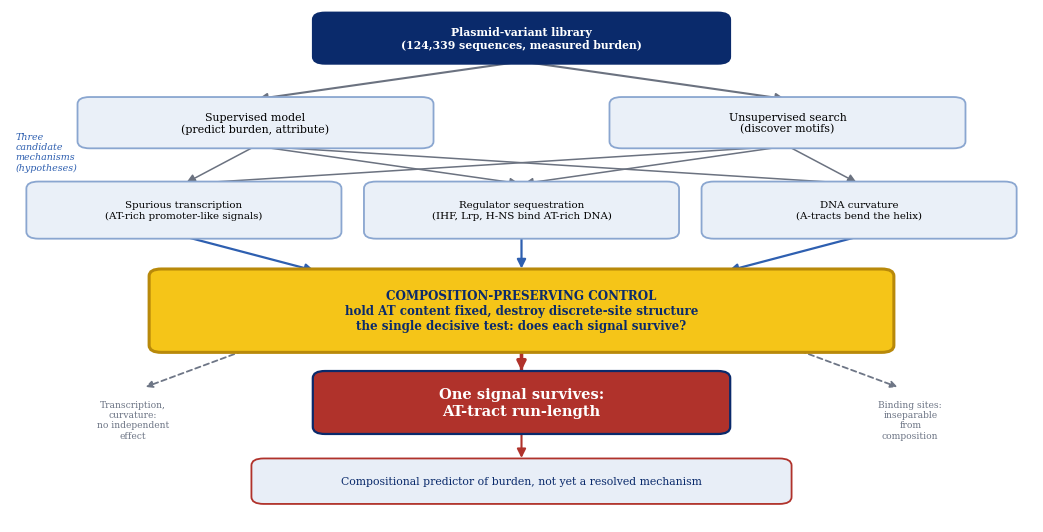

In [ ]:
# =====================================================================
# FIGURE 2 - Study overview (Colab-runnable)
# Composition-preserving CONTROL is the visual pivot; three candidate
# mechanisms are HYPOTHESES that collapse under it, leaving one axis.
# Place at END OF INTRODUCTION, after "...inseparable ... on sequence alone."
# =====================================================================
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
import matplotlib as mpl
mpl.rcParams.update({'font.family':'serif','font.size':9})
NAVY='#0A2A6B'; BLUE='#2E5FB0'; GREY='#6B7280'; RED='#B0322B'; LIGHT='#E8EEF7'
HYPO='#EAF0F8'; HYPO_ED='#8AA6D0'; PIVOT='#F5C518'; PIVOT_ED='#B8890A'; FADE='#6E7686'

fig, ax = plt.subplots(figsize=(10.5, 5.4)); ax.set_xlim(0,10); ax.set_ylim(1.1,9.9); ax.axis('off')

BOXES={}
def box(key,x,y,w,h,text,fc=LIGHT,ec=NAVY,tc='black',fs=8.5,bold=False,lw=1.3):
    ax.add_patch(FancyBboxPatch((x,y),w,h,boxstyle="round,pad=0.04,rounding_size=0.12",fc=fc,ec=ec,lw=lw,zorder=2))
    ax.text(x+w/2,y+h/2,text,ha='center',va='center',fontsize=fs,color=tc,fontweight='bold' if bold else 'normal',zorder=3)
    BOXES[key]=(x,y,w,h)
def top(k): x,y,w,h=BOXES[k]; return (x+w/2,y+h)
def bot(k): x,y,w,h=BOXES[k]; return (x+w/2,y)
def A(p1,p2,color=GREY,lw=1.5,ls='-'):
    ax.add_patch(FancyArrowPatch(p1,p2,arrowstyle='-|>',mutation_scale=13,lw=lw,color=color,zorder=1,linestyle=ls))

# ---- library + two arms ----
box('lib',3.0,9.0,4.0,0.8,"Plasmid-variant library\n(124,339 sequences, measured burden)",fc=NAVY,tc='white',fs=7.8,bold=True)
box('sup',0.7,7.55,3.4,0.8,"Supervised model\n(predict burden, attribute)",fc=HYPO,ec=HYPO_ED,fs=7.9)
box('uns',5.9,7.55,3.4,0.8,"Unsupervised search\n(discover motifs)",fc=HYPO,ec=HYPO_ED,fs=7.9)
A(bot('lib'),top('sup'),GREY); A(bot('lib'),top('uns'),GREY)

# ---- three candidate mechanisms (label placed at far LEFT, clear of the fan arrows) ----
box('spur',0.2,6.0,3.0,0.9,"Spurious transcription\n(AT-rich promoter-like signals)",fc=HYPO,ec=HYPO_ED,fs=7.4)
box('seq', 3.5,6.0,3.0,0.9,"Regulator sequestration\n(IHF, Lrp, H-NS bind AT-rich DNA)",fc=HYPO,ec=HYPO_ED,fs=7.4)
box('curv',6.8,6.0,3.0,0.9,"DNA curvature\n(A-tracts bend the helix)",fc=HYPO,ec=HYPO_ED,fs=7.4)
ax.text(0.05,7.45,"Three\ncandidate\nmechanisms\n(hypotheses)",ha='left',va='center',fontsize=6.8,style='italic',color=BLUE,zorder=5)
for m in ['spur','seq','curv']:
    A(bot('sup'),top(m),GREY,lw=1.1); A(bot('uns'),top(m),GREY,lw=1.1)

# ---- THE PIVOT: composition-preserving control (large, central) ----
box('ctrl',1.4,4.05,7.2,1.35,
    "COMPOSITION-PRESERVING CONTROL\nhold AT content fixed, destroy discrete-site structure\n"
    "the single decisive test: does each signal survive?",
    fc=PIVOT,ec=PIVOT_ED,tc=NAVY,fs=8.6,bold=True,lw=2.2)
for m in ['spur','seq','curv']:
    A(bot(m),(top('ctrl')[0]+(-2.0 if m=='spur' else (0 if m=='seq' else 2.0)),top('ctrl')[1]),BLUE,lw=1.6)

# ---- collapse: one survives (short red arrow), others drop away (dashed, readable grey) ----
A(bot('ctrl'),top('axis') if 'axis' in BOXES else (5.0,2.55),RED,lw=2.4)  # placeholder; drawn after axis below
box('axis',3.0,2.65,4.0,1.0,"One signal survives:\nAT-tract run-length",fc=RED,tc='white',fs=10.5,bold=True,lw=1.6)
# redraw the short red arrow now that axis exists
A((5.0,4.05),top('axis'),RED,lw=2.4)

# dashed collapse arrows to the sides + readable labels
ax.add_patch(FancyArrowPatch((2.3,4.05),(1.3,3.4),arrowstyle='-|>',mutation_scale=10,lw=1.3,color=FADE,zorder=1,linestyle=(0,(3,2))))
ax.add_patch(FancyArrowPatch((7.7,4.05),(8.7,3.4),arrowstyle='-|>',mutation_scale=10,lw=1.3,color=FADE,zorder=1,linestyle=(0,(3,2))))
ax.text(1.2,3.2,"Transcription,\ncurvature:\nno independent\neffect",ha='center',va='top',fontsize=6.6,color=FADE,zorder=4)
ax.text(8.8,3.2,"Binding sites:\ninseparable\nfrom\ncomposition",ha='center',va='top',fontsize=6.6,color=FADE,zorder=4)

# ---- conclusion ----
box('concl',2.4,1.45,5.2,0.7,"Compositional predictor of burden, not yet a resolved mechanism",
    fc=LIGHT,ec=RED,tc=NAVY,fs=7.8)
A(bot('axis'),top('concl'),RED,lw=1.5)

plt.tight_layout()
plt.savefig('figure2_project_overview.png',dpi=600,bbox_inches='tight')
print("saved")
# from google.colab import files; files.download('figure2_project_overview.png')

saved


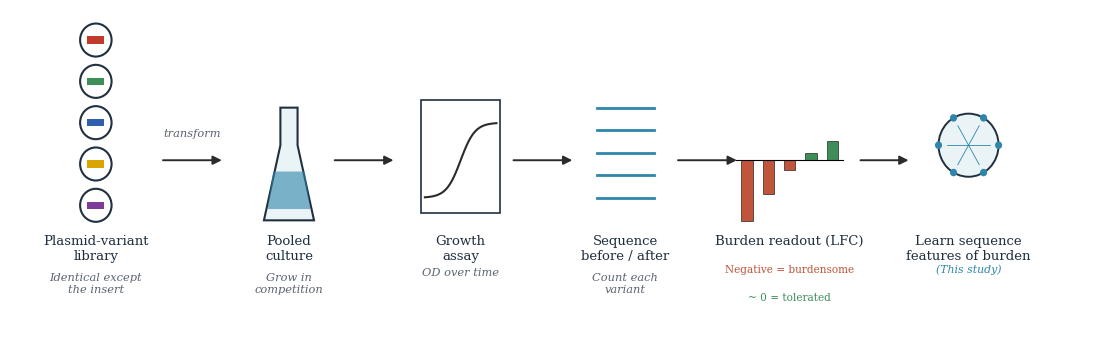

In [ ]:
# =====================================================================
# FIGURE 3 - Degenerate-library fitness assay workflow (Colab-runnable)
# Styled after Copeman thesis Fig 2.1: horizontal icon workflow.
# Place in BACKGROUND 2.2, after: "...an LFC near zero means it was tolerated."
# =====================================================================
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle, Rectangle, Polygon
import matplotlib as mpl, numpy as np
mpl.rcParams.update({'font.family':'serif','font.size':9})
TEAL='#2E86AB'; NAVY='#20303F'; GREY='#5A6472'; RED='#C0553B'; GREEN='#3E8E5A'; INK='#2B2B2B'; LIGHT='#EAF3F6'

fig, ax = plt.subplots(figsize=(11.0, 3.5)); ax.set_xlim(0,15); ax.set_ylim(1.7,6.0); ax.axis('off')

def label(x,y,t,fs=9.5): ax.text(x,y,t,ha='center',va='top',fontsize=fs,color=NAVY)
def step(x,y,t): ax.text(x,y,t,ha='center',va='center',fontsize=8.2,color=GREY,style='italic')
def arrow(x1,y1,x2,y2,c=INK): ax.add_patch(FancyArrowPatch((x1,y1),(x2,y2),arrowstyle='-|>',mutation_scale=13,lw=1.4,color=c))

# ---- 1. Pool of variants (stacked plasmid circles w/ colored inserts) ----
cols=['#C0392B','#3E8E5A','#2E5FB0','#D9A404','#7D3C98','#1C86C6']
for k in range(5):
    y=5.6-k*0.55
    ax.add_patch(Circle((1.2,y),0.22,fc='none',ec=NAVY,lw=1.5))
    ax.add_patch(Rectangle((1.08,y-0.05),0.24,0.10,fc=cols[k],ec='none'))
label(1.2,3.0,"Plasmid-variant\nlibrary")
step(1.2,2.35,"Identical except\nthe insert")

arrow(2.1,4.0,3.0,4.0); step(2.55,4.35,"transform")

# ---- 2. Bacterial culture (flask) ----
fx=3.9
ax.add_patch(Polygon([(fx-0.35,3.2),(fx-0.12,4.2),(fx-0.12,4.7),(fx+0.12,4.7),(fx+0.12,4.2),(fx+0.35,3.2)],closed=True,fc=LIGHT,ec=NAVY,lw=1.5))
ax.add_patch(Polygon([(fx-0.30,3.35),(fx+0.30,3.35),(fx+0.22,3.85),(fx-0.22,3.85)],closed=True,fc=TEAL,ec='none',alpha=0.6))
label(fx,3.0,"Pooled\nculture")
step(fx,2.35,"Grow in\ncompetition")

arrow(fx+0.6,4.0,fx+1.5,4.0)

# ---- 3. Growth assay (OD curve) ----
gx=6.3
ax.add_patch(Rectangle((gx-0.55,3.3),1.1,1.5,fc='white',ec=NAVY,lw=1.2))
xx=np.linspace(0,1,50); ax.plot(gx-0.5+xx*1.0, 3.5+1.0/(1+np.exp(-(xx-0.5)*10)), color=INK, lw=1.5)
label(gx,3.0,"Growth\nassay")
step(gx,2.5,"OD over time")

arrow(gx+0.7,4.0,gx+1.6,4.0)

# ---- 4. Sequencing (reads) ----
sx=8.6
for i,yy in enumerate(np.linspace(3.5,4.7,5)):
    ax.plot([sx-0.4,sx+0.4],[yy,yy],color=TEAL,lw=2)
label(sx,3.0,"Sequence\nbefore / after")
step(sx,2.35,"Count each\nvariant")

arrow(sx+0.7,4.0,sx+1.6,4.0)

# ---- 5. LFC readout (bar chart up/down) ----
lx=10.9
vals=[-0.9,-0.5,-0.15,0.1,0.28]; bxs=np.linspace(lx-0.6,lx+0.6,5)
for x,v in zip(bxs,vals): ax.add_patch(Rectangle((x-0.08,4.0),0.16,v*0.9,fc=RED if v<0 else GREEN,ec='black',lw=0.4))
ax.plot([lx-0.75,lx+0.75],[4.0,4.0],color='black',lw=0.8)
label(lx,3.0,"Burden readout (LFC)")
ax.text(lx,2.5,"Negative = burdensome",fontsize=7.6,color=RED,ha='center')
ax.text(lx,2.12,"~ 0 = tolerated",fontsize=7.6,color=GREEN,ha='center')

arrow(lx+0.95,4.0,lx+1.7,4.0)

# ---- 6. ML / patterns (this study) ----
mx=13.4
ax.add_patch(Circle((mx,4.2),0.42,fc=LIGHT,ec=NAVY,lw=1.4))
for a in np.linspace(0,2*np.pi,7)[:-1]:
    ax.add_patch(Circle((mx+0.42*np.cos(a),4.2+0.42*np.sin(a)),0.05,fc=TEAL,ec='none'))
    ax.plot([mx,mx+0.30*np.cos(a)],[4.2,4.2+0.30*np.sin(a)],color=TEAL,lw=0.6)
label(mx,3.0,"Learn sequence\nfeatures of burden")
ax.text(mx,2.5,"(This study)",fontsize=7.8,color=TEAL,ha='center',style='italic')

plt.tight_layout(); plt.savefig('figure3_assay_schematic.png',dpi=600,bbox_inches='tight')
print("saved")
# from google.colab import files; files.download('figure3_assay_schematic.png')